## 65010406 Tanadon Aunyart
---
#### `Title` : Calories Burnt Prediction 

In [1]:
#Setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy import stats


In [2]:
df = pd.read_csv('calories.csv')
# เอา column User_Id, Gender ออกเนื่องจากเป็น Text
df = df.drop(df.columns[[ 0,1 ]], axis=1)
df.head()




,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,69,179.0,79.0,5.0,88.0,38.7,26.0
3,34,179.0,71.0,13.0,100.0,40.5,71.0
4,27,154.0,58.0,10.0,81.0,39.8,35.0


In [3]:
df.dtypes

#ตรวจสอบข้อมูลที่หายไป
df.isnull().sum()

Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

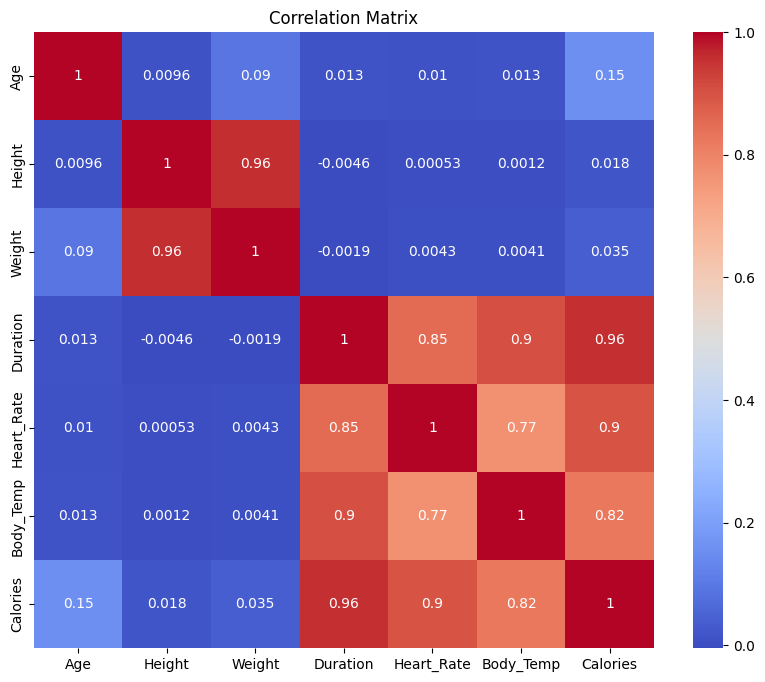

In [4]:
correlation_matrix = df.corr()
correlation_matrix.style.background_gradient()

# คำนวณค่า Correlation
correlation_matrix = df.corr()

# แสดงความสัมพันธ์ในรูปแบบ Heatmap
df = df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [5]:
# เลือกตัวแปร
X = df[['Age', 'Height', 'Weight','Duration', 'Heart_Rate','Body_Temp']].values
y = df['Calories'].values

# เพิ่มคอลัมน์ของค่า 1 สำหรับ bias
X = np.hstack((np.ones((X.shape[0], 1)), X))


In [6]:
# ฟังก์ชันคำนวณค่า Cost
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/2*m) * np.sum(np.square(predictions - y))
    return cost

# ฟังก์ชัน Gradient Descent
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)
    
    for i in range(iterations):
        predictions = X.dot(theta)
        errors = predictions - y
        theta -= (learning_rate/m) * X.T.dot(errors)
        cost_history[i] = compute_cost(X, y, theta)
    
    return theta, cost_history


Theta (พารามิเตอร์): [-0.03101751  0.37856314 -1.5543762   1.36611535  4.69457871  2.14193018
 -0.87863673]
ค่า Cost สุดท้าย: 22400157857.04799


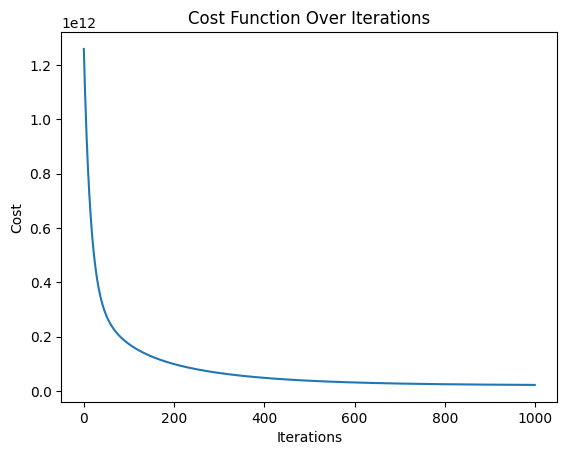

In [7]:
# กำหนดพารามิเตอร์เริ่มต้น
theta = np.zeros(X.shape[1])
learning_rate = 0.00004 #มากกว่านี้จะเกิด overshooting
iterations = 1000

# เรียกใช้ Gradient Descent
theta, cost_history = gradient_descent(X, y, theta, learning_rate, iterations)

# แสดงผลลัพธ์
print("Theta (พารามิเตอร์):", theta)
print("ค่า Cost สุดท้าย:", cost_history[-1])

plt.plot(range(iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function Over Iterations')
plt.show()



In [8]:
# ทำนายผลลัพธ์
predictions = X.dot(theta)
print("Predicted Calories Burnt:", predictions[:5])  # แสดงผลลัพธ์ 5 ตัวแรก


Predicted Calories Burnt: [183.99171404  63.13719577  33.73912003  71.23873304  35.52333261]


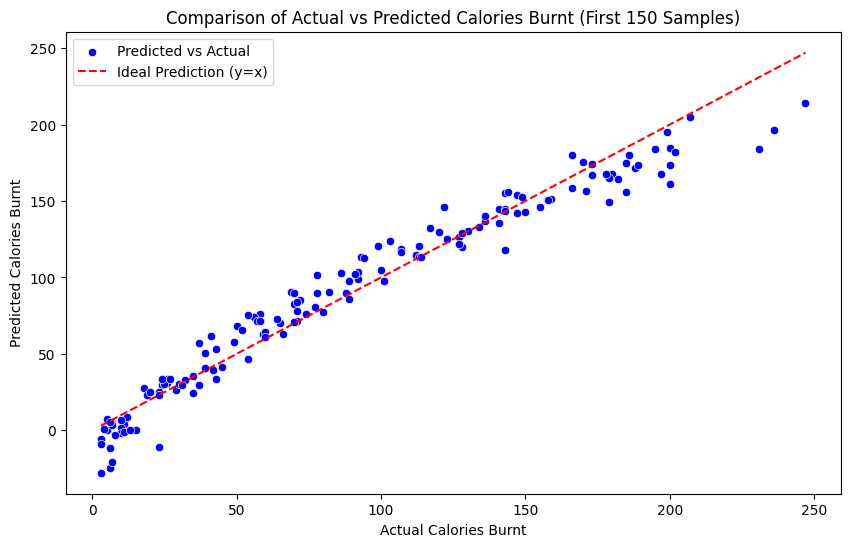

In [9]:
#  x = (Actual Calories Burnt)
#  y = (Predicted Calories Burnt)
# แสดงข้อมูลสำหรับ 150 ตัวแรก
actual = y[:150]
predicted = predictions[:150]

# สร้าง DataFrame สำหรับแสดงข้อมูล
comparison_df = pd.DataFrame({'Actual': actual, 'Predicted': predicted})

# สร้างกราฟ
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(x='Actual', y='Predicted', data=comparison_df, color='blue', label='Predicted vs Actual')

# วาดเส้น ideal (y=x)
plt.plot([min(actual), max(actual)], [min(actual), max(actual)], color='red', linestyle='--', label='Ideal Prediction (y=x)')

# ตั้งชื่อกราฟ
plt.title('Comparison of Actual vs Predicted Calories Burnt (First 150 Samples)')
plt.xlabel('Actual Calories Burnt')
plt.ylabel('Predicted Calories Burnt')

# แสดงกราฟ
plt.legend()
plt.show()
